# 제주 특산물 가격 예측 - 앙상블 v3.1.0

| 항목 | 내용 |
|------|------|
| **버전** | v3.1.0 |
| **날짜** | 2026-03-12 |
| **모델** | DNN(v1.2.0) + CatBoost + XGBoost 앙상블 |
| **전처리** | v1.0.1 동일 |
| **출력** | results/submission_v3.1.0.csv |

## v3.1.0 변경 내용 (v3.0.0 대비)
| 항목 | v3.0.0 | v3.1.0 |
|------|--------|--------|
| DNN | 기본 Dense (v1.0.1 구조) | **Embedding + Residual (v1.2.0 구조)** |
| CatBoost | 동일 | 동일 |
| XGBoost | 동일 | 동일 |
| 기대 효과 | — | DNN이 더 강해져 앙상블 전체 성능 향상 |

---
## 1. 라이브러리 로드

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, datetime, random, os, platform
warnings.filterwarnings('ignore')

import holidays

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from catboost import CatBoostRegressor
import xgboost as xgb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 2024
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)

print(f'TF: {tf.__version__} | CatBoost: {__import__("catboost").__version__} | XGB: {xgb.__version__}')

TF: 2.20.0 | CatBoost: 1.2.10 | XGB: 3.2.0


---
## 2. 데이터 로드

In [28]:
DATA_PATH = '../data/'
train = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv', encoding='utf-8-sig')
print(f'train: {train.shape}, test: {test.shape}')

train: (59397, 7), test: (1092, 5)


---
## 3. 전처리 + 이상치 + 타겟 변환 (v1.0.1 동일)

In [29]:
def pre_all(train, test):
    train['timestamp'] = pd.to_datetime(train['timestamp'])
    test['timestamp']  = pd.to_datetime(test['timestamp'])
    df = pd.concat([train, test]).reset_index(drop=True)
    df.rename(columns={'supply(kg)': 'supply', 'price(원/kg)': 'price'}, inplace=True)

    df['year']     = df['timestamp'].dt.year
    df['month']    = df['timestamp'].dt.month
    df['day']      = df['timestamp'].dt.day
    df['week_day'] = df['timestamp'].dt.weekday

    le = LabelEncoder()
    df['year_month'] = df['timestamp'].map(lambda x: f'{x.year}-{x.month}')
    df['year_month'] = le.fit_transform(df['year_month'])

    df['week'] = df['timestamp'].map(
        lambda x: datetime.datetime(x.year, x.month, x.day).isocalendar()[1]
    )
    week_offsets = {2019: 0, 2020: 52, 2021: 52+53, 2022: 52+53+53, 2023: 52+53+53+52}
    df['week_num'] = df.apply(lambda r: int(r['week']) + week_offsets.get(r['year'], 0), axis=1)
    df.loc[df['timestamp'] == '2019-12-30', 'week_num'] = 52
    df.loc[df['timestamp'] == '2019-12-31', 'week_num'] = 52

    kr_holi = holidays.KR()
    df['holiday'] = df['timestamp'].map(lambda x: 1 if x in kr_holi else 0)

    train_out = df[~df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    test_out  = df[ df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    print(f'전처리 완료 — train: {train_out.shape}, test: {test_out.shape}')
    return train_out, test_out

train_pre, test_pre = pre_all(train, test)

outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    idx = train_pre[(train_pre['item'] == item) & (train_pre['price'] > thr)].index
    if len(idx):
        mean_p = train_pre[(train_pre['item'] == item) & (train_pre['price'] != 0)]['price'].mean()
        train_pre.loc[idx, 'price'] = mean_p
        print(f'{item}: {len(idx)}개 이상치 → 평균({mean_p:.0f})')

train_pre['price_transformed'] = np.where(
    train_pre['item'] == 'TG',
    np.sqrt(train_pre['price']),
    np.log1p(train_pre['price'])
)

tg_mask = (train_pre['item'] == 'TG') & (train_pre['holiday'] == 1) & (train_pre['price'] != 0)
active_holi = list(train_pre[tg_mask].groupby('timestamp').count().reset_index()['timestamp'])
fix_idx = train_pre[train_pre['timestamp'].isin(active_holi)].index
train_pre.loc[fix_idx, 'holiday'] = 0
print(f'TG 공휴일 보정: {len(fix_idx)}개')

전처리 완료 — train: (59397, 15), test: (1092, 15)
TG: 1개 이상치 → 평균(4145)
RD: 1개 이상치 → 평균(564)
BC: 1개 이상치 → 평균(2757)
CB: 7개 이상치 → 평균(715)
TG 공휴일 보정: 1521개


---
## 4. 공통 학습/검증 분리

In [30]:
TARGET_TRF = 'price_transformed'
TARGET_COL = 'price'

tr_sorted = train_pre.sort_values('year_month').reset_index(drop=True)
sp        = int(len(tr_sorted) * 0.8)
train_df  = tr_sorted.iloc[:sp]
val_df    = tr_sorted.iloc[sp:]

y_tr      = train_df[TARGET_TRF].values.astype(np.float32)
y_vl      = val_df[TARGET_TRF].values.astype(np.float32)
y_vl_orig = val_df[TARGET_COL].values
is_tg_vl  = (val_df['item'] == 'TG').values

def inverse_transform(y_trf, is_tg):
    result = np.where(
        is_tg.astype(bool),
        np.power(np.clip(y_trf, 0, None), 2),
        np.expm1(y_trf)
    )
    return np.clip(result, 0, None)

def eval_model(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f'  [{name}]  MAE={mae:>8,.1f}  RMSE={rmse:>8,.1f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return mae, rmse, r2, mape

print(f'학습: {len(train_df):,}행, 검증: {len(val_df):,}행')

학습: 47,517행, 검증: 11,880행


---
## 5. 모델 1 — DNN v1.2.0 (Embedding + Residual)

> v1.2.0에서 정의한 `build_dnn_residual` 구조 그대로 사용

In [31]:
NUM_FEAT_COLS = ['year', 'month', 'day', 'week_day', 'year_month', 'week_num', 'holiday']

item_le = LabelEncoder().fit(pd.concat([train_pre['item'], test_pre['item']]))
corp_le = LabelEncoder().fit(pd.concat([train_pre['corporation'], test_pre['corporation']]))
loc_le  = LabelEncoder().fit(pd.concat([train_pre['location'], test_pre['location']]))

N_ITEMS = len(item_le.classes_)
N_CORPS = len(corp_le.classes_)
N_LOCS  = len(loc_le.classes_)

EMB_DIM_ITEM = min(50, max(2, (N_ITEMS + 1) // 2))
EMB_DIM_CORP = min(50, max(2, (N_CORPS + 1) // 2))
EMB_DIM_LOC  = min(50, max(2, (N_LOCS  + 1) // 2))

def prepare_inputs(df, scaler=None):
    X_num = df[NUM_FEAT_COLS].values.astype(np.float32)
    if scaler is not None:
        X_num = scaler.transform(X_num)
    X_item = item_le.transform(df['item']).reshape(-1, 1).astype(np.int32)
    X_corp = corp_le.transform(df['corporation']).reshape(-1, 1).astype(np.int32)
    X_loc  = loc_le.transform(df['location']).reshape(-1, 1).astype(np.int32)
    return [X_num, X_item, X_corp, X_loc]

num_scaler  = StandardScaler()
num_scaler.fit(train_df[NUM_FEAT_COLS].values)

dnn_inputs_tr   = prepare_inputs(train_df,  num_scaler)
dnn_inputs_vl   = prepare_inputs(val_df,    num_scaler)
dnn_inputs_test = prepare_inputs(test_pre,  num_scaler)

print(f'DNN 입력 준비 완료 — 수치({len(NUM_FEAT_COLS)}) + item emb({EMB_DIM_ITEM}) + corp emb({EMB_DIM_CORP}) + loc emb({EMB_DIM_LOC})')

DNN 입력 준비 완료 — 수치(7) + item emb(3) + corp emb(3) + loc emb(2)


In [32]:
def residual_block(x, units, dropout=0.0, l2_reg=1e-4):
    l2 = regularizers.l2(l2_reg)
    shortcut = layers.Dense(units, kernel_regularizer=l2)(x)
    shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Dense(units, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    x = layers.Dense(units, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_dnn_residual(n_num, n_items, n_corps, n_locs,
                        emb_dim_item, emb_dim_corp, emb_dim_loc, lr=1e-3):
    l2 = regularizers.l2(1e-4)

    inp_num  = keras.Input(shape=(n_num,), name='numeric')
    inp_item = keras.Input(shape=(1,),     name='item')
    inp_corp = keras.Input(shape=(1,),     name='corp')
    inp_loc  = keras.Input(shape=(1,),     name='loc')

    e_item = layers.Flatten()(layers.Embedding(n_items, emb_dim_item, name='emb_item')(inp_item))
    e_corp = layers.Flatten()(layers.Embedding(n_corps, emb_dim_corp, name='emb_corp')(inp_corp))
    e_loc  = layers.Flatten()(layers.Embedding(n_locs,  emb_dim_loc,  name='emb_loc')(inp_loc))

    x = layers.Concatenate()([inp_num, e_item, e_corp, e_loc])
    x = layers.Dense(256, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = residual_block(x, units=128, dropout=0.2)
    x = residual_block(x, units=64,  dropout=0.1)

    out = layers.Dense(1)(x)
    model = keras.Model([inp_num, inp_item, inp_corp, inp_loc], out, name='dnn_residual_v3.1')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mae', metrics=['mse'])
    return model


os.makedirs('./models',  exist_ok=True)
os.makedirs('./results', exist_ok=True)

dnn_model = build_dnn_residual(
    len(NUM_FEAT_COLS), N_ITEMS, N_CORPS, N_LOCS,
    EMB_DIM_ITEM, EMB_DIM_CORP, EMB_DIM_LOC
)

dnn_cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=20,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=8, min_lr=1e-6, verbose=0),
    callbacks.ModelCheckpoint('./models/dnn_residual_v3.1.0.keras',
                              monitor='val_loss', save_best_only=True, verbose=0)
]

dnn_history = dnn_model.fit(
    dnn_inputs_tr, y_tr,
    validation_data=(dnn_inputs_vl, y_vl),
    epochs=200, batch_size=512,
    callbacks=dnn_cb, verbose=1
)

dnn_best = np.argmin(dnn_history.history['val_loss'])
print(f'DNN Best Epoch: {dnn_best}')

Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 12.5116 - mse: 698.7119 - val_loss: 13.6595 - val_mse: 780.1031 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.1526 - mse: 316.8331 - val_loss: 9.1800 - val_mse: 325.0531 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 4.9220 - mse: 130.7909 - val_loss: 7.1800 - val_mse: 196.7619 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.9002 - mse: 108.3067 - val_loss: 6.0594 - val_mse: 156.1517 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.6451 - mse: 107.8447 - val_loss: 4.5911 - val_mse: 124.9514 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.5210 - mse: 106.8404 - val_loss: 4.3886 - val_mse: 125.8326 - learning_rate: 0.0010
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.4355 - mse: 108.1721 - val_loss: 4.1435 - val_mse: 125.7682 

---
## 6. 모델 2 — CatBoost (v3.0.0 동일)

In [33]:
CAT_COLS  = ['item', 'corporation', 'location']
TIME_COLS = ['year_month', 'week_num', 'week_day', 'month', 'day', 'holiday', 'year']
CB_FEAT   = TIME_COLS + CAT_COLS

X_cb_tr   = train_df[CB_FEAT]
y_cb_tr   = train_df[TARGET_TRF].values
X_cb_vl   = val_df[CB_FEAT]
y_cb_vl   = val_df[TARGET_TRF].values
X_cb_test = test_pre[CB_FEAT]

cb_is_tg_vl   = (val_df['item'] == 'TG').values
cb_vl_orig    = val_df[TARGET_COL].values
cb_test_is_tg = (test_pre['item'] == 'TG').values

cb_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE',
    eval_metric='MAE',
    cat_features=CAT_COLS,
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200
)
cb_model.fit(X_cb_tr, y_cb_tr, eval_set=(X_cb_vl, y_cb_vl), use_best_model=True)
print(f'CatBoost 최적 반복: {cb_model.get_best_iteration()}')

0:	learn: 12.5446566	test: 14.6777836	best: 14.6777836 (0)	total: 95.5ms	remaining: 4m 46s
200:	learn: 3.2251291	test: 3.8734031	best: 3.8734031 (200)	total: 16.4s	remaining: 3m 48s
400:	learn: 3.0409827	test: 3.7510998	best: 3.7510647 (378)	total: 32.3s	remaining: 3m 29s
600:	learn: 2.9745787	test: 3.7214432	best: 3.7213959 (597)	total: 48.4s	remaining: 3m 13s
800:	learn: 2.9199335	test: 3.7084472	best: 3.7065614 (789)	total: 1m 4s	remaining: 2m 55s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 3.706561361
bestIteration = 789

Shrink model to first 790 iterations.
CatBoost 최적 반복: 789


---
## 7. 모델 3 — XGBoost (v3.0.0 동일)

In [34]:
# XGBoost: get_dummies 인코딩
drop_cols_train = ['supply', 'timestamp', 'week']
drop_cols_test  = ['supply', 'timestamp', 'week', 'price']

Xy_all = pd.get_dummies(
    train_pre.drop(columns=drop_cols_train),
    columns=['item', 'corporation', 'location']
).sort_values('ID').reset_index(drop=True)

test_enc = pd.get_dummies(
    test_pre.drop(columns=drop_cols_test),
    columns=['item', 'corporation', 'location']
).sort_values('ID').reset_index(drop=True)

for col in Xy_all.columns:
    if col not in test_enc.columns:
        test_enc[col] = 0

XGB_FEAT_COLS = [c for c in Xy_all.columns
                  if c not in ['ID', 'price', 'price_transformed', 'is_tg']]

# train_df / val_df 와 같은 ID 순서로 정렬
Xy_tr = Xy_all[Xy_all['ID'].isin(train_df['ID'])].sort_values('ID')
Xy_vl = Xy_all[Xy_all['ID'].isin(val_df['ID'])].sort_values('ID')

X_xgb_tr    = Xy_tr[XGB_FEAT_COLS].values
y_xgb_tr    = Xy_tr[TARGET_TRF].values
X_xgb_vl    = Xy_vl[XGB_FEAT_COLS].values
y_xgb_vl    = Xy_vl[TARGET_TRF].values
xgb_is_tg   = Xy_vl.get('item_TG', pd.Series([False]*len(Xy_vl))).values.astype(bool)
xgb_vl_orig = Xy_vl[TARGET_COL].values
X_xgb_test  = test_enc[XGB_FEAT_COLS].values
xgb_test_is_tg = test_enc.get('item_TG', pd.Series([False]*len(test_enc))).values.astype(bool)

xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:absoluteerror',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=100
)
xgb_model.fit(
    X_xgb_tr, y_xgb_tr,
    eval_set=[(X_xgb_vl, y_xgb_vl)],
    verbose=200
)
print(f'XGB 최적 반복: {xgb_model.best_iteration}')

[0]	validation_0-mae:14.63095
[200]	validation_0-mae:4.85438
[349]	validation_0-mae:4.83857
XGB 최적 반복: 249


---
## 8. 개별 모델 검증 성능 비교

In [35]:
# DNN 예측
dnn_vl_pred_trf = dnn_model.predict(dnn_inputs_vl, verbose=0).flatten()
dnn_vl_pred     = inverse_transform(dnn_vl_pred_trf, is_tg_vl)

# CatBoost 예측
cb_vl_pred_trf = cb_model.predict(X_cb_vl)
cb_vl_pred     = inverse_transform(cb_vl_pred_trf, cb_is_tg_vl)

# XGBoost 예측
xgb_vl_pred_trf = xgb_model.predict(X_xgb_vl)
xgb_vl_pred     = inverse_transform(xgb_vl_pred_trf, xgb_is_tg)

print('=' * 70)
print('  개별 모델 검증 성능')
print('=' * 70)
dnn_scores = eval_model(y_vl_orig,  dnn_vl_pred,  'DNN v1.2')
cb_scores  = eval_model(cb_vl_orig, cb_vl_pred,   'CatBoost')
xgb_scores = eval_model(xgb_vl_orig, xgb_vl_pred, 'XGBoost ')
print('=' * 70)

  개별 모델 검증 성능
  [DNN v1.2]  MAE=   532.0  RMSE= 1,196.6  R²=0.7183  MAPE=1324705310623.14%
  [CatBoost]  MAE=   512.0  RMSE= 1,162.8  R²=0.7339  MAPE=1256428270773.61%
  [XGBoost ]  MAE=   687.3  RMSE= 1,359.6  R²=0.6363  MAPE=1138535705382.84%


---
## 9. 앙상블 (가중치 최적화)

In [36]:
# DNN / XGBoost 는 val_df 기준, CatBoost 는 train_df/val_df 같은 분할이라 동일
# 단, xgb_vl_orig 와 y_vl_orig 는 같은 ID를 다른 순서로 정렬했을 수 있으므로
# 공통 val_df ID 기준으로 재정렬
val_ids = val_df['ID'].values

id2dnn  = dict(zip(val_df['ID'].values, dnn_vl_pred))
id2cb   = dict(zip(val_df['ID'].values, cb_vl_pred))
id2xgb  = dict(zip(Xy_vl['ID'].values, xgb_vl_pred))
id2true = dict(zip(val_df['ID'].values, y_vl_orig))

common_ids = sorted(set(id2dnn) & set(id2cb) & set(id2xgb))
arr_true = np.array([id2true[i]  for i in common_ids])
arr_dnn  = np.array([id2dnn[i]   for i in common_ids])
arr_cb   = np.array([id2cb[i]    for i in common_ids])
arr_xgb  = np.array([id2xgb[i]  for i in common_ids])

# 방법 1: MAE 역수 비례
inv_w = np.array([1/dnn_scores[0], 1/cb_scores[0], 1/xgb_scores[0]])
inv_w /= inv_w.sum()
ens_inv = inv_w[0]*arr_dnn + inv_w[1]*arr_cb + inv_w[2]*arr_xgb
mae_inv = mean_absolute_error(arr_true, ens_inv)
print(f'역수 가중치  DNN={inv_w[0]:.3f} CB={inv_w[1]:.3f} XGB={inv_w[2]:.3f}  MAE={mae_inv:,.2f}')

# 방법 2: scipy 최적화
def ens_loss(w):
    w = np.abs(w) / np.abs(w).sum()
    return mean_absolute_error(arr_true, w[0]*arr_dnn + w[1]*arr_cb + w[2]*arr_xgb)

res = minimize(ens_loss, x0=[1/3, 1/3, 1/3], method='Nelder-Mead',
               options={'maxiter': 2000, 'xatol': 1e-5})
opt_w = np.abs(res.x) / np.abs(res.x).sum()
ens_opt = opt_w[0]*arr_dnn + opt_w[1]*arr_cb + opt_w[2]*arr_xgb
mae_opt = mean_absolute_error(arr_true, ens_opt)
print(f'최적화 가중치 DNN={opt_w[0]:.3f} CB={opt_w[1]:.3f} XGB={opt_w[2]:.3f}  MAE={mae_opt:,.2f}')

w_final = opt_w if mae_opt <= mae_inv else inv_w
print(f'\n→ {"최적화" if mae_opt <= mae_inv else "역수"} 가중치 사용')

역수 가중치  DNN=0.355 CB=0.369 XGB=0.275  MAE=537.00
최적화 가중치 DNN=0.339 CB=0.661 XGB=0.000  MAE=504.91

→ 최적화 가중치 사용


In [37]:
ens_vl_pred = w_final[0]*arr_dnn + w_final[1]*arr_cb + w_final[2]*arr_xgb

mae  = mean_absolute_error(arr_true, ens_vl_pred)
rmse = np.sqrt(mean_squared_error(arr_true, ens_vl_pred))
r2   = r2_score(arr_true, ens_vl_pred)
mape = np.mean(np.abs((arr_true - ens_vl_pred) / (arr_true + 1e-8))) * 100

print('=' * 60)
print('  앙상블 v3.1.0 검증 성능')
print('=' * 60)
print(f'  가중치  DNN={w_final[0]:.3f}  CB={w_final[1]:.3f}  XGB={w_final[2]:.3f}')
print(f'  MAE  : {mae:>10,.2f} 원/kg')
print(f'  RMSE : {rmse:>10,.2f} 원/kg')
print(f'  R²   : {r2:>10.4f}')
print(f'  MAPE : {mape:>10.2f} %')
print('=' * 60)

  앙상블 v3.1.0 검증 성능
  가중치  DNN=0.339  CB=0.661  XGB=0.000
  MAE  :     504.91 원/kg
  RMSE :   1,156.00 원/kg
  R²   :     0.7370
  MAPE : 1279581866926.38 %


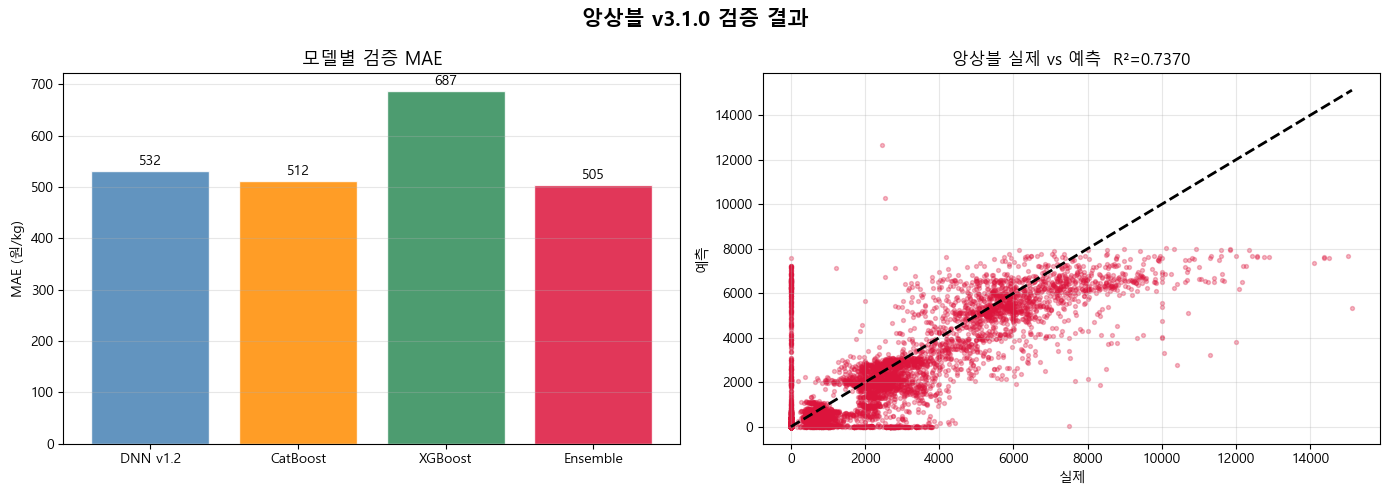

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = ['DNN v1.2', 'CatBoost', 'XGBoost', 'Ensemble']
maes = [dnn_scores[0], cb_scores[0], xgb_scores[0], mae]
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

bars = axes[0].bar(model_names, maes, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('모델별 검증 MAE', fontsize=13)
axes[0].set_ylabel('MAE (원/kg)')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

max_v = max(arr_true.max(), ens_vl_pred.max())
axes[1].scatter(arr_true, ens_vl_pred, alpha=0.3, s=8, color='crimson')
axes[1].plot([0, max_v], [0, max_v], 'k--', lw=2)
axes[1].set_title(f'앙상블 실제 vs 예측  R²={r2:.4f}', fontsize=12)
axes[1].set_xlabel('실제'); axes[1].set_ylabel('예측'); axes[1].grid(alpha=0.3)

plt.suptitle('앙상블 v3.1.0 검증 결과', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/ensemble_eval_v3.1.0.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 테스트 예측 + 후처리 + 제출

In [39]:
dnn_test_trf  = dnn_model.predict(dnn_inputs_test, verbose=0).flatten()
cb_test_trf   = cb_model.predict(X_cb_test)
xgb_test_trf  = xgb_model.predict(X_xgb_test)

dnn_test_pred = inverse_transform(dnn_test_trf,  (test_pre['item'] == 'TG').values)
cb_test_pred  = inverse_transform(cb_test_trf,   cb_test_is_tg)
xgb_test_pred = inverse_transform(xgb_test_trf,  xgb_test_is_tg)

# test_pre 기준 정렬 (DNN, CatBoost는 test_pre 순서)
# XGBoost는 test_enc 순서 → test_pre 와 ID 매핑
id2xgb_test = dict(zip(test_enc['ID'].values, xgb_test_pred))
xgb_test_pred_aligned = np.array([id2xgb_test.get(i, 0.0) for i in test_pre['ID'].values])

ens_test_pred = (w_final[0] * dnn_test_pred
               + w_final[1] * cb_test_pred
               + w_final[2] * xgb_test_pred_aligned)
ens_test_pred = np.clip(ens_test_pred, 0, None)

result_df = test_pre[['ID', 'item']].copy()
result_df['answer'] = ens_test_pred

min_thresholds = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for item, thr in min_thresholds.items():
    mask = (result_df['item'] == item) & (result_df['answer'] < thr)
    result_df.loc[mask, 'answer'] = 0.0
    if mask.sum() > 0:
        print(f'{item}: {mask.sum()}개 → 0 처리')

print('\n예측 통계:')
print(result_df.groupby('item')['answer'].agg(['mean','min','max']).round(1))

TG: 40개 → 0 처리
CB: 44개 → 0 처리
RD: 56개 → 0 처리
CR: 76개 → 0 처리
BC: 84개 → 0 처리

예측 통계:
        mean  min     max
item                     
BC    1687.9  0.0  4444.4
CB     333.1  0.0   821.8
CR     395.9  0.0  1246.6
RD     471.8  0.0  1500.3
TG    2878.5  0.0  3992.5


In [40]:
result = sub[['ID']].merge(result_df[['ID', 'answer']], on='ID', how='left')
result['answer'] = result['answer'].fillna(0.0)

SUBMISSION_PATH = './results/submission_v3.1.0.csv'
result.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8-sig')
print(f'저장: {SUBMISSION_PATH}, 행: {len(result)}')
result.head(10)

저장: ./results/submission_v3.1.0.csv, 행: 1092


,ID,answer
0,TG_A_J_20230304,2616.325334
1,TG_A_J_20230305,0.000000
2,TG_A_J_20230306,2719.611878
3,TG_A_J_20230307,2714.759031
4,TG_A_J_20230308,2714.150505
5,TG_A_J_20230309,2710.992757
6,TG_A_J_20230310,2716.785379
7,TG_A_J_20230311,2682.356406
8,TG_A_J_20230312,0.000000
9,TG_A_J_20230313,2805.833873


---
## 11. 결과 요약

In [41]:
print('=' * 65)
print('  앙상블 v3.1.0 최종 결과')
print('=' * 65)
print(f'  가중치  DNN={w_final[0]:.3f}  CatBoost={w_final[1]:.3f}  XGBoost={w_final[2]:.3f}')
print()
print('  [DNN 구조] Embedding + Residual Block (v1.2.0)')
print(f'    item emb={EMB_DIM_ITEM} / corp emb={EMB_DIM_CORP} / loc emb={EMB_DIM_LOC}')
print(f'    Residual: 256→128→64')
print()
print('  [개별 모델 검증 MAE]')
print(f'    DNN v1.2  : {dnn_scores[0]:>10,.2f} 원/kg')
print(f'    CatBoost  : {cb_scores[0]:>10,.2f} 원/kg')
print(f'    XGBoost   : {xgb_scores[0]:>10,.2f} 원/kg')
print()
print('  [앙상블 검증 성능]')
print(f'    MAE  = {mae:>10,.2f} 원/kg')
print(f'    RMSE = {rmse:>10,.2f} 원/kg')
print(f'    R²   = {r2:>10.4f}')
print(f'    MAPE = {mape:>10.2f} %')
print()
print(f'  제출 파일: {SUBMISSION_PATH}')
print('=' * 65)

  앙상블 v3.1.0 최종 결과
  가중치  DNN=0.339  CatBoost=0.661  XGBoost=0.000

  [DNN 구조] Embedding + Residual Block (v1.2.0)
    item emb=3 / corp emb=3 / loc emb=2
    Residual: 256→128→64

  [개별 모델 검증 MAE]
    DNN v1.2  :     532.01 원/kg
    CatBoost  :     511.97 원/kg
    XGBoost   :     687.29 원/kg

  [앙상블 검증 성능]
    MAE  =     504.91 원/kg
    RMSE =   1,156.00 원/kg
    R²   =     0.7370
    MAPE = 1279581866926.38 %

  제출 파일: ./results/submission_v3.1.0.csv


### 다음 버전

| 버전 | 개선 내용 |
|------|----------|
| **v3.2.0** | LightGBM 추가 (4모델 앙상블) |
| **v3.3.0** | Stacking (Ridge 메타 러너) |
| **v4.0.0** | LSTM(v2) + 트리 모델 앙상블 |